In [59]:
import torch
import time
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from src.utils.helpers import generate_response, format_example
from src.evaluation.eval import log_parser, evaluate_to_dataframe

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# 1. Base Model Preparation

In [60]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [61]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

response = generate_response(model, tokenizer, prompt)
print(response)

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

3. Plan Trip:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

4. Check Weather:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

5. Search for Accommod


In [5]:
result = generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=80,
    benchmark=True
)
print(result["text"])
print()
print(np.round(result["total_time_s"],2))
print(np.round(result["generated_tokens"],2))
print(np.round(result["tokens_per_second"],2))

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to

8.21
80
9.74


# 2. LoRA Finetune 

In [6]:
curr_dir = Path.cwd()
curr_dir.is_dir()

True

In [7]:
output_dir = curr_dir.parent/"outputs"/"models"
output_dir.is_dir()

True

In [8]:
[item for item in curr_dir.parent.iterdir()]

[WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/.git'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/.gitignore'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/.ipynb_checkpoints'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/.python-version'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/configs'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/LICENSE'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/main.py'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/models'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/notebooks'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/outputs'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/mo

In [9]:
datasets_dir = curr_dir.parent/"datasets"/"structured_json"
datasets_dir.is_dir()

True

In [10]:
[item for item in datasets_dir.iterdir()]

[WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets/structured_json/TEST_travel_tool_routing_20_samples.jsonl'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets/structured_json/TEST_travel_tool_routing_20_samples_prompted_v2.jsonl'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets/structured_json/TRAIN_travel_tool_routing_100_samples.jsonl'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets/structured_json/TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets/structured_json/VAL_travel_tool_routing_20_samples.jsonl'),
 WindowsPath('C:/Users/DFS/Desktop/gitrepo/workshops/model-alignment-lab/datasets/structured_json/VAL_travel_tool_routing_20_samples_prompted_v2.jsonl')]

In [11]:
train_path = datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl") #datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples.jsonl")
train_path.is_file()

True

In [12]:
test_path = datasets_dir.joinpath("TEST_travel_tool_routing_20_samples_prompted_v2.jsonl")
test_path.is_file()

True

In [13]:
val_path = datasets_dir.joinpath("VAL_travel_tool_routing_20_samples_prompted_v2.jsonl")
val_path.is_file()

True

## Load the Dataset

In [14]:
from datasets import load_dataset

train_dataset = load_dataset("json", 
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

In [15]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 100
})

In [16]:
val_dataset

Dataset({
    features: ['messages'],
    num_rows: 20
})

In [17]:
test_dataset

Dataset({
    features: ['messages'],
    num_rows: 20
})

In [18]:
train_dataset["messages"][1]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nCheck flights from Los Angeles to Tokyo for a trip starting 2026-07-12 and ending 2026-07-18. Use the travel tool schema.'},
 {'role': 'assistant',
  'content': '{"tool": "search_flights", "arguments": {"origin": "Los Angeles", "destination": "Tokyo", "departure_date": "2026-07-12", "return_date": "2026-07-18"}}'}]

In [20]:
train_dataset = train_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
val_dataset = val_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})
test_dataset = test_dataset.map(format_example, fn_kwargs={"tokenizer":tokenizer})

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [21]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 100
})

In [22]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>



In [23]:
print(val_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Please help. Can you create a trip plan for Vancouver from 2026-08-21 through 2026-08-26 on a high budget? Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "plan_trip", "arguments": {"destination": "Vancouver", "start_date": "2026-08-21", "end_date": "2026-08-26", "budget_level": "HIGH"}}<|im_end|>



In [24]:
for i in [0, 5, 10]:
    print("=" * 80)
    print(train_dataset["text"][i])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- c

In [25]:
print(repr(train_dataset["text"][0]))

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nReturn ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nQuick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>\n<|im_start|>assistant\n{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>\n'


### LoRA Setup

In [26]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"]
)


In [27]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [28]:
model.print_trainable_parameters()

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508


## Training

In [29]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-tool-routing-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=True,
    bf16=False,
    fp16=False,
)

In [30]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.416023,1.359528
2,0.847128,0.817218
3,0.611867,0.607318


TrainOutput(global_step=75, training_loss=1.1369877084096274, metrics={'train_runtime': 1999.8621, 'train_samples_per_second': 0.15, 'train_steps_per_second': 0.038, 'total_flos': 125084943705600.0, 'train_loss': 1.1369877084096274})

In [32]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [33]:
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_time_check")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_time_check")

('C:\\Users\\DFS\\Desktop\\gitrepo\\workshops\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_111642_final_adapter_time_check\\tokenizer_config.json',
 'C:\\Users\\DFS\\Desktop\\gitrepo\\workshops\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_111642_final_adapter_time_check\\chat_template.jinja',
 'C:\\Users\\DFS\\Desktop\\gitrepo\\workshops\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_111642_final_adapter_time_check\\tokenizer.json')

## Model Evaluation

In [34]:
trainer.state.log_history

[{'loss': 1.9261741638183594,
  'grad_norm': 0.07781308144330978,
  'learning_rate': 0.00018933333333333335,
  'entropy': 1.4544593930244445,
  'num_tokens': 4383.0,
  'mean_token_accuracy': 0.6608457535505294,
  'epoch': 0.2,
  'step': 5},
 {'loss': 1.7917415618896484,
  'grad_norm': 0.08295881748199463,
  'learning_rate': 0.00017600000000000002,
  'entropy': 1.4664753556251526,
  'num_tokens': 8816.0,
  'mean_token_accuracy': 0.6699722826480865,
  'epoch': 0.4,
  'step': 10},
 {'loss': 1.6707393646240234,
  'grad_norm': 0.09502562880516052,
  'learning_rate': 0.00016266666666666667,
  'entropy': 1.500051462650299,
  'num_tokens': 13317.0,
  'mean_token_accuracy': 0.6881201952695847,
  'epoch': 0.6,
  'step': 15},
 {'loss': 1.5800517082214356,
  'grad_norm': 0.11147262901067734,
  'learning_rate': 0.00014933333333333335,
  'entropy': 1.5571526110172271,
  'num_tokens': 17587.0,
  'mean_token_accuracy': 0.707253384590149,
  'epoch': 0.8,
  'step': 20},
 {'loss': 1.416023063659668,
  'g

In [35]:
len(trainer.state.log_history)

19

In [36]:
# epoch = []
# loss = []
# eval_loss = []

# for log in trainer.state.log_history:
#     if log["epoch"] % 1.0 == 0:
#         if "loss" in log:
#             epoch.append(log["epoch"])
#             loss.append(log["loss"])
#         elif "eval_loss" in log:
#             eval_loss.append(log["eval_loss"])
#         else:
#             continue
        
epoch,loss,eval_loss = log_parser(trainer)

print(epoch)
print(loss)
print(eval_loss)

[1.0, 2.0, 3.0]
[1.416023063659668, 0.8471280097961426, 0.611866807937622]
[1.3595283031463623, 0.8172176480293274, 0.6073183417320251]


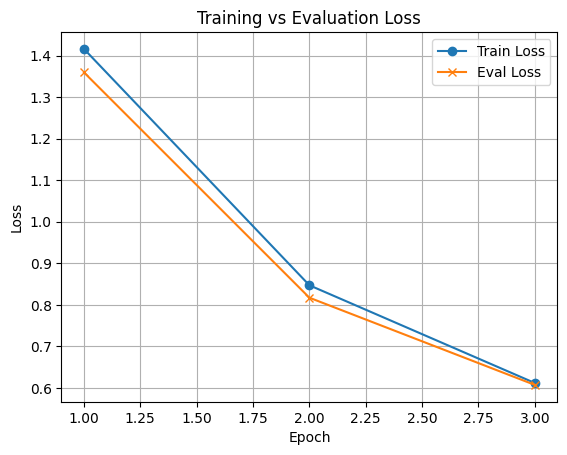

In [37]:
import matplotlib.pyplot as plt

figure, ax = plt.subplots()
ax.plot(epoch, loss, marker="o", label="Train Loss")
ax.plot(epoch, eval_loss, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [38]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

response = generate_response(model, tokenizer, prompt)
print(response)
# messages = [
#     {"role": "user", "content": prompt}
# ]

# inputs = tokenizer.apply_chat_template(
#     messages,
#     tokenize=True,
#     add_generation_prompt=True,
#     return_tensors="pt"
# )

# inputs = {k: v.to(model.device) for k,v in inputs.items()} # This moves vectors to whatever device user is using

# with torch.no_grad():
#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=180,
#         do_sample=False
#     )
# input_len = inputs["input_ids"].shape[1]
# generated_ids = outputs[0][input_len:]
# print(tokenizer.decode(generated_ids, skip_special_tokens=True))

{"tool": "search_flights", "arguments": {"origin": "San Diego", "destination": "New York", "departure_date": "2026-05-10", "return_date": "2026-05-15"}}


In [39]:
test_dataset["text"][0]

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nReturn ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nTravel request: I want an itinerary for London from 2026-05-10 to 2026-05-15 with high spending. Please respond with JSON only.<|im_end|>\n<|im_start|>assistant\n{"tool": "plan_trip", "arguments": {"destination": "London", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "HIGH"}}<|im_end|>\n'

In [42]:
# import json
# import pandas as pd

# def evaluate_to_dataframe(model, tokenizer, dataset):
#     rows = []
#     systemish = """
#     Return ONLY valid JSON.

#     Available tools:
#     - search_flights(origin, destination, departure_date, return_date)
#     - search_hotels(location, check_in_date, check_out_date)
#     - plan_trip(destination, start_date, end_date, budget_level)
#     - check_weather(location, date)
    
#     Use exact tool names and exact argument keys.
    
#     User request:
#     """
#     for i, sample in enumerate(dataset):
#         prompt = sample["messages"][0]["content"]
#         reference = sample["messages"][1]["content"]

#         pred = generate_response(model, tokenizer, prompt)

#         # defaults
#         pred_tool = None
#         pred_args = None
#         actual_tool = None
#         actual_args = None
#         valid_json = False

#         try:
#             pred_json = json.loads(pred)
#             valid_json = True
#             pred_tool = pred_json.get("tool")
#             pred_args = pred_json.get("arguments")
#         except:
#             pass

#         try:
#             ref_json = json.loads(reference)
#             actual_tool = ref_json.get("tool")
#             actual_args = ref_json.get("arguments")
#         except:
#             pass

#         rows.append({
#             "prompt": prompt,
#             "pred_tool": pred_tool,
#             "actual_tool": actual_tool,
#             "tool_match": pred_tool == actual_tool,
#             "pred_arguments": pred_args,
#             "actual_arguments": actual_args,
#             "arguments_match": pred_args == actual_args,
#             "valid_json": valid_json,
#             "prediction_raw": pred,
#             "reference_raw": reference
#         })

#     df = pd.DataFrame(rows)
#     return df

In [43]:
df = evaluate_to_dataframe(model, tokenizer, test_dataset)
df.head()

Task was destroyed but it is pending!
task: <Task pending name='Task-237' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\DFS\Desktop\gitrepo\workshops\model-alignment-lab\venv_x86\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-238' coro=<Kernel.shell_main() running at C:\Users\DFS\Desktop\gitrepo\workshops\model-alignment-lab\venv_x86\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\DFS\Desktop\gitrepo\workshops\model-alignment-lab\venv_x86\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\DFS\Desktop\gitrepo\workshops\model-alignment-lab\venv_x86\Lib\site-packages\torch\nn\modules\module.py:1784: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  forward_call = (self._slow_forward if torch._C._get_tracing_state() else self.forward)
Task was destroyed but it is pending!
task: <Task pending name='Task-238' coro=<Kernel.she

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_flights,plan_trip,False,"{'origin': 'London', 'destination': 'London', ...","{'destination': 'London', 'start_date': '2026-...",False,True,"{""tool"": ""search_flights"", ""arguments"": {""orig...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",False,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'Honolulu', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""locatio...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'New York', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""New Yor...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,weather_schemalike,check_weather,False,None,"{'location': 'Paris', 'date': '2026-08-21'}",False,True,"{""tool"": ""weather_schemalike"", ""argument_keys""...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [44]:
df.tool_match.value_counts()

tool_match
True     13
False     7
Name: count, dtype: int64

In [45]:
df.arguments_match.value_counts()

arguments_match
False    13
True      7
Name: count, dtype: int64

In [46]:
df.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

## Train mas

In [47]:
# Increase number of epochs
trainer.args.num_train_epochs = 6
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.281519,0.277498
2,0.188918,0.207984
3,0.174317,0.175354
4,0.150773,0.164309
5,0.153337,0.155541
6,0.140509,0.153809


TrainOutput(global_step=150, training_loss=0.2024765706062317, metrics={'train_runtime': 3106.647, 'train_samples_per_second': 0.193, 'train_steps_per_second': 0.048, 'total_flos': 250169887411200.0, 'train_loss': 0.2024765706062317})

## Model v2 Eval

In [48]:
# epoch = []
# loss = []
# eval_loss = []

# for log in trainer.state.log_history:
#     if log["epoch"] % 1.0 == 0:
#         if "loss" in log:
#             epoch.append(log["epoch"])
#             loss.append(log["loss"])
#         elif "eval_loss" in log:
#             eval_loss.append(log["eval_loss"])
#         else:
#             continue

epoch,loss,eval_loss = log_parser(trainer)

print(epoch)
print(loss)
print(eval_loss)

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
[0.28151850700378417, 0.1889175295829773, 0.17431749105453492, 0.15077303647994994, 0.15333744287490844, 0.1405090570449829]
[0.2774980664253235, 0.20798449218273163, 0.17535358667373657, 0.16430941224098206, 0.15554127097129822, 0.15380874276161194]


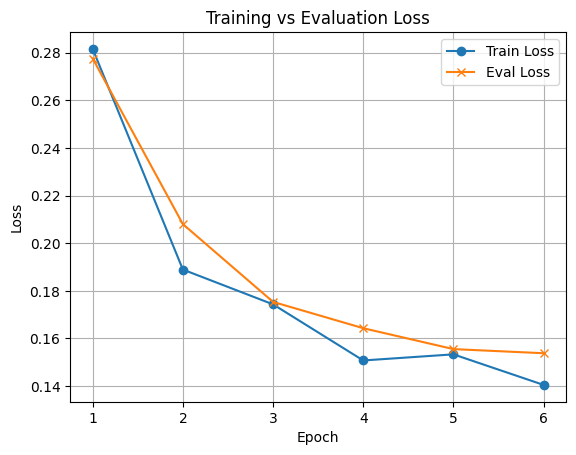

In [49]:
figure, ax = plt.subplots()
ax.plot(epoch, loss, marker="o", label="Train Loss")
ax.plot(epoch, eval_loss, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [51]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

generate_response(model, tokenizer, prompt)

'{"tool": "plan_trip", "arguments": {"destination": "New York", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "MEDIUM"}}'

In [52]:
df_2 = evaluate_to_dataframe(model, tokenizer, test_dataset)
df_2.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'London', 'start_date': '2026-...","{'destination': 'London', 'start_date': '2026-...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'Honolulu', 'check_in_date': '202...","{'location': 'Honolulu', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'New York', 'check_in_date': '202...","{'location': 'New York', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,check_weather,check_weather,True,"{'location': 'Paris', 'date': '2026-08-21'}","{'location': 'Paris', 'date': '2026-08-21'}",True,True,"{""tool"": ""check_weather"", ""arguments"": {""locat...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [53]:
df_2.tool_match.value_counts()

tool_match
True    20
Name: count, dtype: int64

In [54]:
df_2.arguments_match.value_counts()

arguments_match
True    20
Name: count, dtype: int64

In [55]:
df_2.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

In [56]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2_timecheck")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2_timecheck")

('C:\\Users\\DFS\\Desktop\\gitrepo\\workshops\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_124531_final_adapter_v2_timecheck\\tokenizer_config.json',
 'C:\\Users\\DFS\\Desktop\\gitrepo\\workshops\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_124531_final_adapter_v2_timecheck\\chat_template.jinja',
 'C:\\Users\\DFS\\Desktop\\gitrepo\\workshops\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_124531_final_adapter_v2_timecheck\\tokenizer.json')